In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

---

## Реализация Наивного Байесовского классификатора

In [2]:
# Класс для выполнения наивной Баейсовской классификации на k классов
class NB:
    def __init__(self):
        self.k = None          # количество классов 
        self.classes = None    # номера классов
        self.means = []        # cписок векторов средних по классам
        self.covs = []         # список матриц ковариаций (или диагональные)
        self.priors = []       # список априорных вероятностей появления классов
        self.predicts = []     # предсказания классов

    # Метод обучения модели
    def train(self, X, y, *, lms=[1, 1]):
        # перефомирование данных
        X_train = np.array(X)    # приведение признаков к типу данных NumPy
        y_train = np.array(y)    # приведение меток к типу данных NumPy
        
        # вычисление номеров классов и их количества 
        self.classes = np.unique(y_train)    # нахождение уникальных меток классов в данных
        self.k = self.classes.size           # расчет количества уникальных классов 
        
        # цикл на вычисление векторов средних, матриц ковариаций и априорных вероятностей для каждого класса
        for i in range(self.k):
            # формирование подвыборки признаков с классом i
            x = X_train[y_train == self.classes[i]]
            
            mean = x.mean(axis=0)             # расчет вектора средних для класса
            cov = np.diag(np.var(x, axis=0))  # расчет диагональной ковариацонной матрицы класса
            prior = lms[i] * x.shape[0] / X_train.shape[0]    # расчет априорной вероятности появления класса
            
            # добавление рассчитаных параметров в список 
            self.means.append(mean)
            self.covs.append(cov)
            self.priors.append(prior)
            
        return self   
    
    # Метод, который возвращает параметры обученной модели 
    def params(self):
        return self.means, self.covs, self.priors
    
    # Метод  предсказания класса для конкретных наблюдений    
    def predict(self, x, *, lms=[1, 1]):
        # перефомирование данных
        x = np.array(x)    # приведение признаков к типу данных NumPy
        
        if x.ndim == 1:
            x = x.reshape(1, -1)
        
        # расчет значения функции правдоподобия для каждого класса
        for i in range(self.k):
            # Вычисление логарифма ненормированной апостерионой вероятности ( argmax P(y|x) )
            score = (
                np.log(lms[i] * self.priors[i])                                          
                - 1/2 * np.log(np.linalg.det(self.covs[i]))                         
                - 1/2 * ((x - self.means[i]) ** 2 @ np.linalg.inv(self.covs[i])).sum(axis=1) 
            )
        
            # добавление полученных апостериоров в список
            self.predicts.append(score)
        
        # Поиск позиции максимального апостериора для каждого из наблюдений из всех классов    
        self.predicts = np.array(self.predicts).argmax(axis=0)
        
        # Индексация полученными позициями классов для получения самого вероятного класса для каждого наблюдения
        pred_classes = self.classes[self.predicts]
        
        return pred_classes

## Графический пример использования NBA (построение плотности для классов)

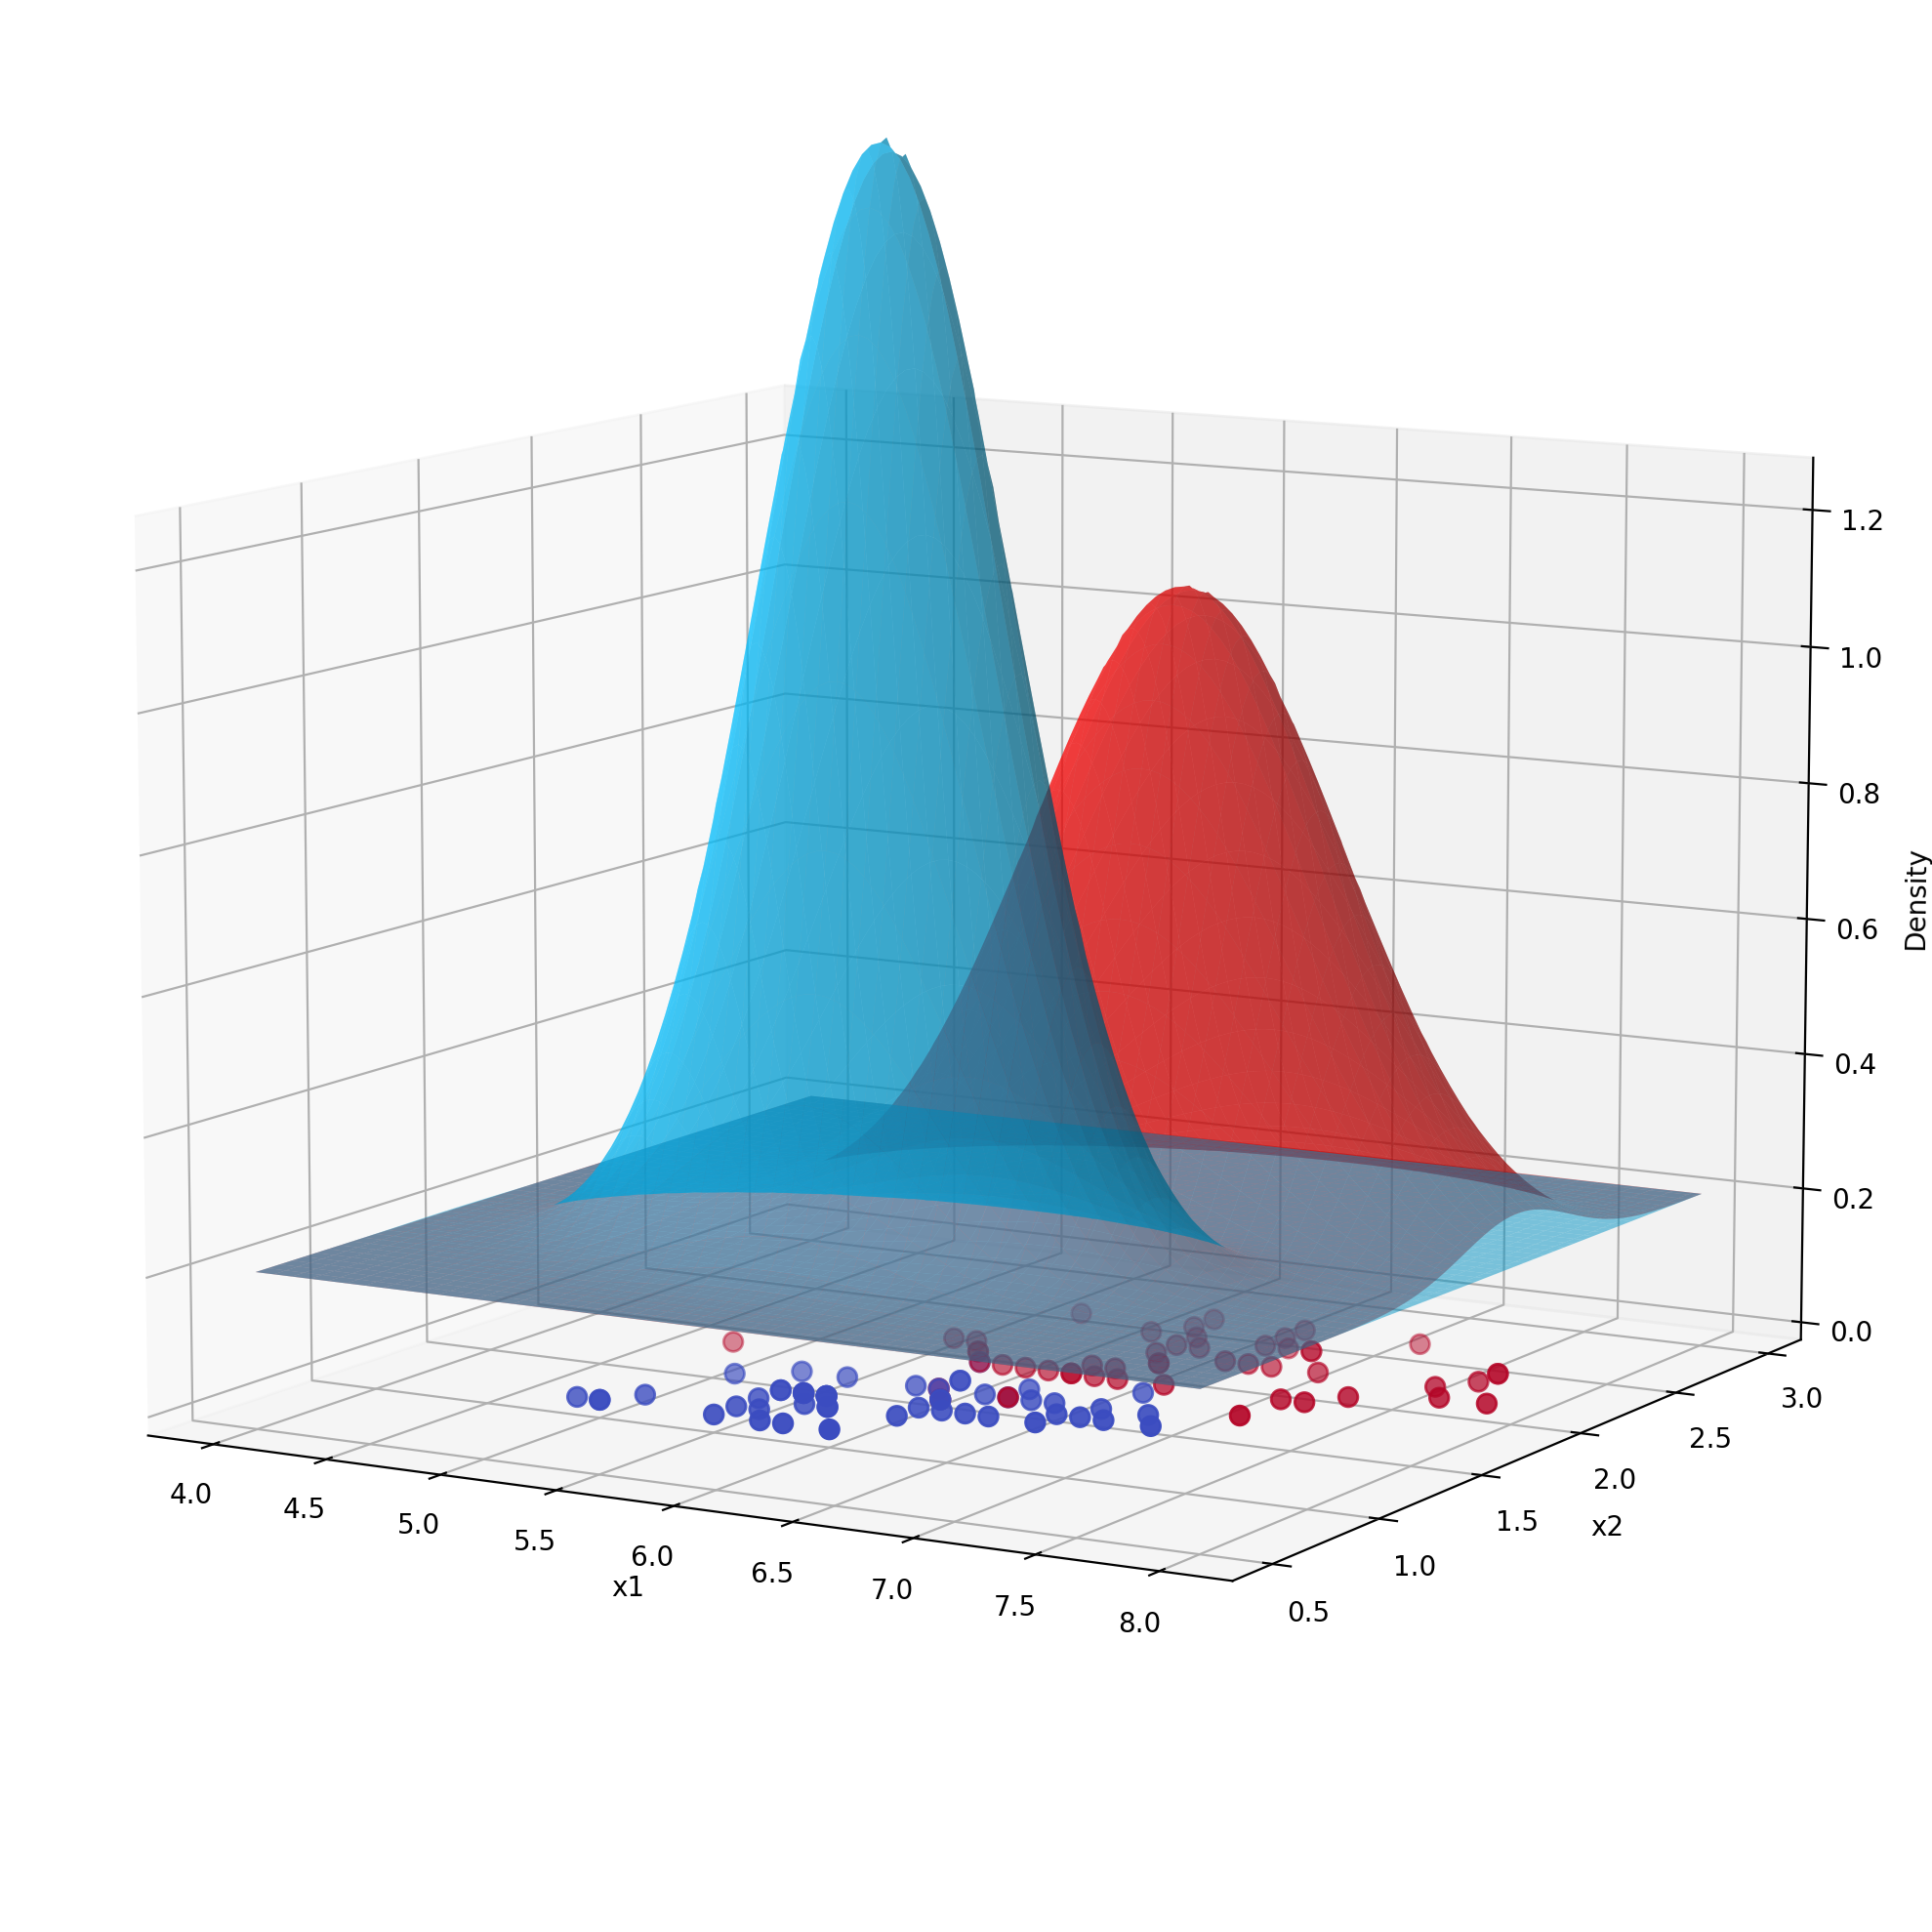

In [6]:
data_x = [(7.2, 2.5), (6.4, 2.2), (6.3, 1.5), (7.7, 2.2), (6.2, 1.8), (5.7, 1.3), (7.1, 2.1), (5.8, 2.4), (5.2, 1.4), (5.9, 1.5), (7.0, 1.4), (6.8, 2.1), (7.2, 1.6), (6.7, 2.4), (6.0, 1.5), (5.1, 1.1), (6.6, 1.3), (6.1, 1.4), (6.7, 2.1), (6.4, 1.8), (5.6, 1.3), (6.9, 2.3), (6.4, 1.9), (6.9, 2.3), (6.5, 2.2), (6.0, 1.5), (5.6, 1.1), (5.6, 1.5), (6.0, 1.0), (6.0, 1.8), (6.7, 2.5), (7.7, 2.3), (5.5, 1.1), (5.8, 1.0), (6.9, 2.1), (6.6, 1.4), (6.3, 1.6), (6.1, 1.4), (5.0, 1.0), (7.7, 2.0), (4.9, 1.7), (7.2, 1.8), (6.8, 1.4), (6.1, 1.2), (5.8, 1.9), (6.3, 2.5), (5.7, 2.0), (6.5, 1.8), (7.6, 2.1), (6.3, 1.5), (6.7, 1.4), (6.4, 2.3), (6.2, 2.3), (6.3, 1.9), (5.5, 1.3), (7.9, 2.0), (6.7, 1.8), (6.4, 1.3), (6.5, 2.0), (6.5, 1.5), (6.9, 1.5), (5.6, 1.3), (5.8, 1.2), (6.7, 2.3), (6.0, 1.6), (5.7, 1.2), (5.7, 1.0), (5.5, 1.0), (6.1, 1.4), (6.3, 1.8), (5.7, 1.3), (6.1, 1.3), (5.5, 1.3), (6.3, 1.3), (5.9, 1.8), (7.7, 2.3), (6.5, 2.0), (5.6, 2.0), (6.7, 1.7), (5.7, 1.3), (5.5, 1.2), (5.0, 1.0), (5.8, 1.9), (6.2, 1.3), (6.2, 1.5), (6.3, 2.4), (6.4, 1.5), (7.4, 1.9), (6.8, 2.3), (5.6, 1.3), (5.8, 1.2), (7.3, 1.8), (6.7, 1.5), (6.3, 1.8), (6.0, 1.6), (6.4, 2.1), (6.1, 1.8), (5.9, 1.8), (5.4, 1.5), (4.9, 1.0)]
data_y = [1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, 1, 1, 1, -1, -1, -1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, -1, -1, 1, 1, 1, -1, -1, 1, -1, -1, -1, -1, 1, 1, 1, -1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, -1, 1, -1, -1, -1, -1, -1, 1, -1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, 1, -1, -1, 1, -1, 1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, -1, -1]

x_train = np.array(data_x)
y_train = np.array(data_y)

lm1 = 1     # штраф неверной классификации 1-го класса (-1)
lm2 = 1     # штраф неверной классификации 2-го класса (+1)

lms = [lm1, lm2]    
    
# Создание объекта (модели)
model = NB()

# Обучение модели
model.train(data_x, data_y, lms=lms)

# Предсказание номеров классов моделью
predict = model.predict(data_x, lms=lms)

# параметры модели для графичского отображения
means, covs, priors = model.params()

# параметры первого класса
mu_1 = np.array([5.936, 1.326])
Sigma_1 = np.array([[0.261104, 0.0], [0.0, 0.038324]])

mu1 = np.array([6.588, 2.026])
Sigma1 = np.array([[0.396256, 0.      ],[0.      , 0.073924]])

# сетка
x1 = np.linspace(4, 8, 100)
x2 = np.linspace(0.5, 3, 100)
xx1, xx2 = np.meshgrid(x1, x2)
pos = np.dstack((xx1, xx2))

# функция плотности нормального распределения
def multivariate_normal_pdf(x, mu, Sigma):
    d = mu.shape[0]
    invS = np.linalg.inv(Sigma)
    detS = np.linalg.det(Sigma)
    norm_const = 1.0 / (np.sqrt((2*np.pi)**d * detS))
    diff = x - mu
    return norm_const * np.exp(-0.5 * np.sum(diff @ invS * diff, axis=-1))

# вычисление плотности
z_1 = multivariate_normal_pdf(pos, mu_1, Sigma_1)

# 3D-график для рапределения точек с классом -1
fig = plt.figure(figsize=(12, 10), dpi=200)
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(xx1, xx2, z_1 + 0.2, alpha=0.5, color='deepskyblue')
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Density")


z1 = multivariate_normal_pdf(pos, mu1, Sigma1)


# 3D-график для рапределения точек с классом 1
ax.plot_surface(xx1, xx2, z1 + 0.2, alpha=0.5, color='red')


ax.set_zlim(0, 1.25)

# scatter на плоскости z=0
ax.scatter(x_train[:,0], x_train[:,1], zs=0, zdir='z', c=y_train, cmap='coolwarm', s=50)

# смена траектории взгляда на график
ax.view_init(elev=10)

# Чтобы все элементы на графике были виды
plt.tight_layout()

plt.show()

---

## Реализация Линейного дискриминантного анализа (LDA)

In [8]:
# Класс для выполнения линейного дискриминантного анализа на k классов
class LDA:
    # Создание параметров используемых во всей программе
    def __init__(self):
        self.k = None
        self.classes = []
        self.priors = []
        self.means = []
        self.pooled_cov = None
        self.predicts = []
        
    
    # Метод обучения модели
    def fit(self, X, y, *, lms = [1, 1]):
        # перефомирование данных
        X_train = np.array(X)    # приведение признаков к типу данных NumPy
        y_train = np.array(y)    # приведение меток к типу данных NumPy

        # вычисление номеров классов и их количества 
        self.classes = np.unique(y_train)    # нахождение уникальных меток классов в данных
        self.k = self.classes.size           # расчет количества уникальных классов 
            
        # вычисление количества объектов в выборке
        l = y_train.shape[0]
        
        # вычисление количества признаков 
        n = X_train.shape[1]
        
        # Начальное создание общей ковариационной матрицы
        self.pooled_cov = np.zeros((n, n))
        
        # цикл на вычисление векторов средних, матриц ковариаций и априорных вероятностей для каждого класса
        for i in range(self.k):
            # формирование подвыборки определенного класса
            X = X_train[y_train == self.classes[i]]
            
            # Расчет выборочных статистик
            mean = X.mean(axis=0)                          # Расчет вектора средних для класса k 
            self.pooled_cov += (X - mean).T @ (X - mean)   # Расчет общей ковариционной матрицы
            prior = lms[i] * X.shape[0] / l
            
            self.means.append(mean)
            self.priors.append(prior)
        
        # Окончательный расчет общей ковариационной матрицы (деление на количество наблюдений)
        self.pooled_cov /= l
        
        return self     
    
    
    # Метод, который возвращает параметры обученной модели 
    def params(self):
        return self.means, self.pooled_cov, self.priors
    
    
    # Метод предсказания классов моделью
    def predict(self, X):
        # перефомирование данных
        X = np.array(X)    # приведение признаков к типу данных NumPy
        
        if X.ndim == 1:
            X = X.reshape(1, X.shape[0])
        
        # Обращенная общая ковариационная матрица
        inv_cov = np.linalg.inv(self.pooled_cov)
        # Расчет значения функции правдоподобия для каждого класса
        for i in range(self.k):
            
            # Расчет ненормированного апостериора
            score = (
            np.log(self.priors[i])
            + np.einsum('ln, nm, m->l', X, inv_cov, self.means[i], optimize="optimal") 
            - 0.5 * np.einsum('n, nm, m->', self.means[i], inv_cov, self.means[i]) 
            )
            
            # Добавление полученного массива апостериора в список
            self.predicts.append(score)
            
        # Поиск позиции максимального апостериора для каждого из наблюдений из всех классов    
        self.predicts = np.array(self.predicts).argmax(axis=0)
        
        # Индексация полученными позициями классов для получения самого вероятного класса для каждого наблюдения
        pred_classes = self.classes[self.predicts]
        
        return pred_classes

---

## Реализация алгоритма Квадратичного дискриминантного анализа QDA

In [3]:
# Класс для выполнения квадратичного дискриминантного анализа на k классов
class QDA:
    # Создание параметров используемых во всей программе
    def __init__(self):
        self.k = None
        self.classes = []
        self.priors = []
        self.means = []
        self.covs = []
        self.predicts = []
    
    # Метод обучения модели
    def fit(self, X, y, *, lms = [1, 1]):
        # перефомирование данных
        X_train = np.array(X)    # приведение признаков к типу данных NumPy
        y_train = np.array(y)    # приведение меток к типу данных NumPy

        # вычисление номеров классов и их количества 
        self.classes = np.unique(y_train)    # нахождение уникальных меток классов в данных
        self.k = self.classes.size           # расчет количества уникальных классов 
            
        # вычисление количества объектов в выборке
        N = y_train.shape[0]

        # цикл на вычисление векторов средних, матриц ковариаций и априорных вероятностей для каждого класса
        for i in range(self.k):
            # формирование подвыборки определенного класса
            X = X_train[y_train == self.classes[i]]
            
            # Расчет выборочных статистик
            mean = X.mean(axis=0)
            cov = np.cov(X.T, ddof=0)
            prior = lms[i] * X.shape[0] / N
            
            self.means.append(mean)
            self.covs.append(cov)
            self.priors.append(prior)
            
        return self     
    
    # Метод, который возвращает параметры обученной модели 
    def params(self):
        return self.means, self.covs, self.priors
    
    # Метод предсказания классов моделью
    def predict(self, X):
        # перефомирование данных
        X = np.array(X)    # приведение признаков к типу данных NumPy
        
        if X.ndim == 1:
            X = X.reshape(1, X.shape[0])
        
        # Расчет значения функции правдоподобия для каждого класса
        for i in range(self.k):
            diff = X - self.means[i]
            inv = np.linalg.inv(self.covs[i])
            
            # Расчет ненормированного апостериора
            score = (
            np.log(self.priors[i])
            - 0.5 * np.log(np.linalg.det(self.covs[i])) 
            - 0.5 * np.einsum('ln, nm, lm->l', diff, inv, diff) 
            )
            
            # Добавление полученного массива апостериора в список
            self.predicts.append(score)
            
            # Поиск позиции максимального апостериора для каждого из наблюдений из всех классов    
        self.predicts = np.array(self.predicts).argmax(axis=0)
        
        # Индексация полученными позициями классов для получения самого вероятного класса для каждого наблюдения
        pred_classes = self.classes[self.predicts]
        
        return pred_classes

## Визуальное сравнение результатов NBA и QDA

Naive Bayes использует диагональные ковариационные матрицы, что означает предположение об условной независимости признаков внутри каждого класса. В результате распределения классов не учитывают корреляции между признаками и гауссианы паралелльны осям.

QDA использует отдельную ковариационную матрицу для каждого класса, которая не обязана быть диагональной:

$$
\Sigma_1 \neq \Sigma_2
$$

что позволяет лучше учитывать различную форму распределений и корреляции между признаками. Из-за этого разделяющие границы QDA могут иметь квадратичную форму.

LDA предполагает одинаковую ковариационную матрицу для всех классов:

$$
\Sigma_1=\Sigma_2=\dots=\Sigma_K
$$

что приводит к линейным разделяющим границам (прямым линиям в двумерном случае).

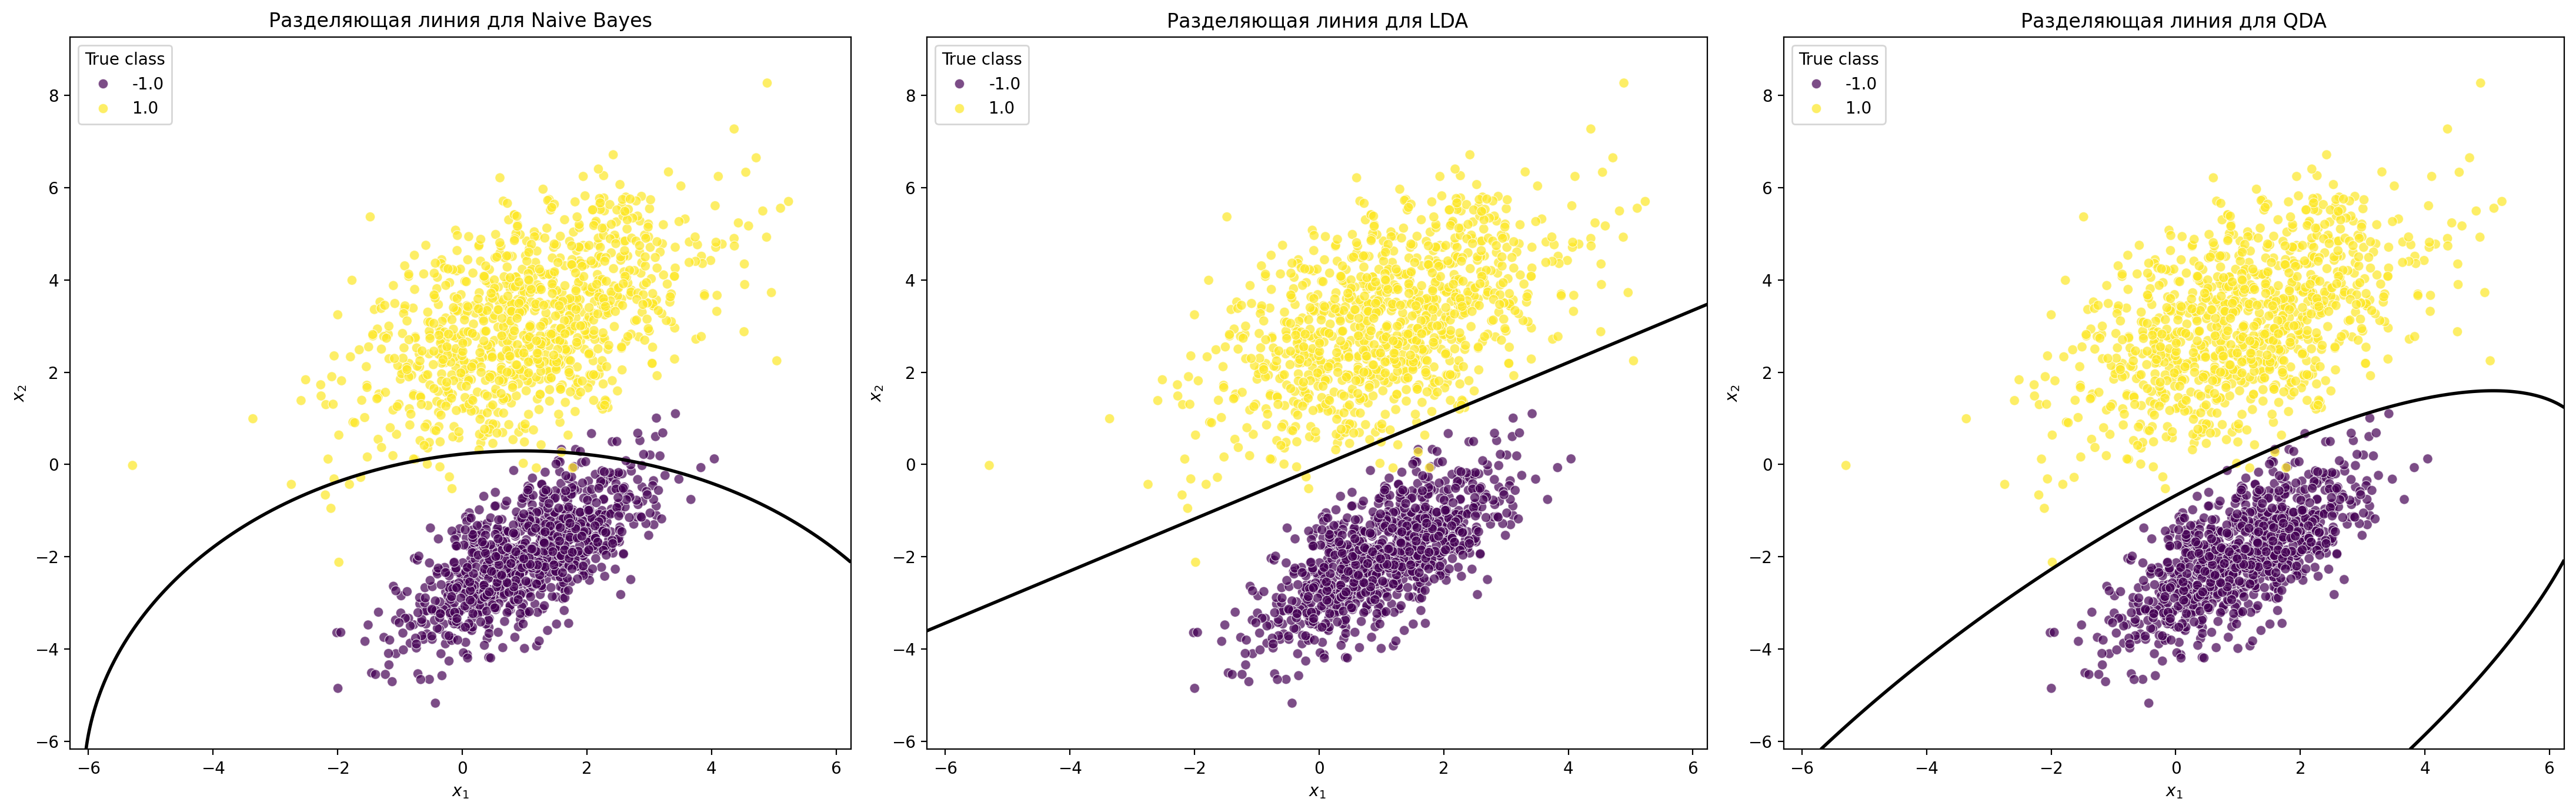

In [23]:
# Генерация последовательностей одинаковых псеводслучайных чисел
np.random.seed(0)

# исходные параметры распределений двух классов
r1 = 0.7
D1 = 1.0
mean1 = [1, -2]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]

r2 = 0.5
D2 = 2.0
mean2 = [1, 3]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

# моделирование обучающей выборки
N = 1000
x1 = np.random.multivariate_normal(mean1, V1, N).T
x2 = np.random.multivariate_normal(mean2, V2, N).T

# обучающая выборка для байесовского классификатора (стандартный формат)
X_train = np.hstack([x1, x2]).T
y_train = np.hstack([np.ones(N) * -1, np.ones(N)])
     
Py1, L1 = 0.5, 1  # вероятности появления классов
Py2, L2 = 1 - Py1, 1  # и величины штрафов неверной классификации

#список штрафов за неверные классификации
lms = [L1, L2]

# Создание объектов классов NB, LDA и QDA 
nb = NB().train(X_train, y_train, lms=lms)
lda = LDA().fit(X_train, y_train, lms=lms)
qda = QDA().fit(X_train, y_train, lms=lms)

means_nb, covs_nb, priors_nb = nb.params()
means_lda, pooled_cov_lda, priors_lda = lda.params()
means_qda, covs_qda, priors_qda = qda.params()


# Функция для QDA / NB
def quadratic_discriminant_function(X, mean, cov, prior):
    diff = X - mean
    inv_cov = np.linalg.inv(cov)

    return (
        np.log(prior)
        - 0.5 * np.log(np.linalg.det(cov))
        - 0.5 * np.einsum("ij,jk,ik->i", diff, inv_cov, diff)
    )


# Функция для LDA
def linear_discriminant_function(X, mean, pooled_cov, prior):
    inv_cov = np.linalg.inv(pooled_cov)

    return (
        np.log(prior)
        + np.einsum("ij,jk,k->i", X, inv_cov, mean)
        - 0.5 * np.einsum("i,ij,j->", mean, inv_cov, mean)
    )


# Создание сетки точек для графика
x1 = np.linspace(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, 300)
x2 = np.linspace(X_train[:, 1].min() - 1, X_train[:, 1].max() + 1, 300)

xx1, xx2 = np.meshgrid(x1, x2)
points = np.c_[xx1.ravel(), xx2.ravel()]


# Создание границ для NB 
g0_nb = quadratic_discriminant_function(points, means_nb[0], covs_nb[0], priors_nb[0])
g1_nb = quadratic_discriminant_function(points, means_nb[1], covs_nb[1], priors_nb[1])
diff_nb = g0_nb - g1_nb


# Создание границ для LDA 
g0_lda = linear_discriminant_function(points, means_lda[0], pooled_cov_lda, priors_lda[0])
g1_lda = linear_discriminant_function(points, means_lda[1], pooled_cov_lda, priors_lda[1])
diff_lda = g0_lda - g1_lda


# Создание границ для QDA
g0_qda = quadratic_discriminant_function(points, means_qda[0], covs_qda[0], priors_qda[0])
g1_qda = quadratic_discriminant_function(points, means_qda[1], covs_qda[1], priors_qda[1])
diff_qda = g0_qda - g1_qda


# Создание графика
fig, axes = plt.subplots(1, 3, figsize=(22, 7), dpi=200)

titles = [
    "Разделяющая линия для Naive Bayes",
    "Разделяющая линия для LDA",
    "Разделяющая линия для QDA"
]

diffs = [diff_nb, diff_lda, diff_qda]

for ax, diff, title in zip(axes, diffs, titles):
    ax.contour(
        xx1,
        xx2,
        diff.reshape(xx1.shape),
        levels=[0],
        colors="black",
        linewidths=2
    )

    sns.scatterplot(
        x=X_train[:, 0],
        y=X_train[:, 1],
        hue=y_train,
        palette="viridis",
        alpha=0.7,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.legend(title="True class")

plt.tight_layout()
plt.show()